In [9]:
import json
import os
import spacy
import networkx as nx
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
import json
from huggingface_hub import HfApi, login


In [10]:
# Load Llama 2 model and tokenizer
model_name = "meta-llama/Llama-2-7b-chat-hf"  
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)


Loading checkpoint shards: 100%|██████████| 2/2 [00:02<00:00,  1.35s/it]


In [72]:
def extract_entities_and_relationships_using_llama2(text):
    prompt = f"""
    Extract entities, attributes, and relationships. Provide the output as a JSON object, with the following structure:
    {{
        "entities": [
            {{"type": "whole", "name": "entity1"}},
            {{"type": "whole", "name": "entity2"}},
            ...
        ],
        "attributes": [
            {{"type": "color", "entity": "entity1", "value": "color1"}},
            {{"type": "state", "entity": "entity2", "value": "state1"}},
            ...
        ],
        "relations": [
            {{"type": "spatial", "entity1": "entity1", "entity2": "entity2", "description": "relation1"}},
            ...
        ]
    }}

    Example:
    Text: "A blue motorcycle parked by paint chipped doors."
    Output:
    {{
        "entities": [
            {{"type": "whole", "name": "motorcycle"}},
            {{"type": "whole", "name": "doors"}}
        ],
        "attributes": [
            {{"type": "color", "entity": "motorcycle", "value": "blue"}},
            {{"type": "state", "entity": "doors", "value": "paint chipped"}},
            {{"type": "state", "entity": "motorcycle", "value": "parked"}}
        ],
        "relations": [
            {{"type": "spatial", "entity1": "motorcycle", "entity2": "doors", "description": "next to"}}
        ]
    }}

    Text: "{text}"

    Output:
    """
    inputs = tokenizer(prompt, return_tensors="pt")
    outputs = model.generate(inputs['input_ids'], max_new_tokens = 500, repetition_penalty=1.1, temperature=0.001)
    response = tokenizer.decode(outputs[0][inputs["input_ids"].shape[-1]:])
    print('Response:')
    print('-'*50)
    print(response)
    print('-'*50)

In [43]:
def extract_entities_and_relationships_using_llama2_CoT(text):
    # Step 1: Extract Concepts
    prompt = f"""
    Extract the concepts from the text and provide the output as a JSON object with the following format:
    {{'concepts': '...', }}

    Example:
    Text: "A blue motorcycle parked by paint chipped doors."
    Concepts: motorcycle (whole), doors (whole), blue (color of motorcycle), painted (state of doors), chipped (state of door paint), parked (state of motorcycle)

    Text: "{text}"
    Concepts:
    """
    inputs = tokenizer(prompt, return_tensors="pt")
    outputs = model.generate(inputs['input_ids'], max_new_tokens=150, repetition_penalty=1.1, temperature=0.01)
    concepts = tokenizer.decode(outputs[0][inputs["input_ids"].shape[-1]:], skip_special_tokens=True).strip()

    print('Concepts obtained from LLama2:', concepts)
    # Step 2: Extract Relationships
    
    concepts = json.loads(concepts)
    prompt = f"""
    Using the extracted concepts, Identify the relationships between them.

    Example:
    Concepts: motorcycle (whole), doors (whole), blue (color of motorcycle), painted (state of doors), chipped (state of door paint), parked (state of motorcycle)
    Relationships: motorcycle -> next to -> doors

    Concepts: {concepts}
    Relationships:
    """
    inputs = tokenizer(prompt, return_tensors="pt")
    outputs = model.generate(inputs['input_ids'], max_new_tokens=150, repetition_penalty=1.1, temperature=0.01)
    relationships = tokenizer.decode(outputs[0][inputs["input_ids"].shape[-1]:], skip_special_tokens=True).strip()
    print('Relationships obtained from LLama2:', relationships)
    return {"concepts": concepts, "relationships": relationships}

In [73]:
response_json_path = "/home/ubuntu/Multimodal-Uncertainty-Quantification/debug_bin_9_10_llava_mmt_output_uq_io_graph_similarity_temp_1_topp_1.json"
with open(response_json_path, 'r') as f:
    response_json = json.load(f)
    for key, value in response_json.items():
        print('Key:', key)
        responses = value['responses']
        for response in responses:
            try:
                print('Explanation:', response['explanation'])
                text = response['explanation']
                print('Text:', text)
                # entities, relationships = extract_entities_and_relationships_using_llama2(text)
                extract_entities_and_relationships_using_llama2(text)
                # extract_entities_and_relationships_using_llama2_CoT(text)
                # print('Entities:', entities)
                # print('Relationships', relationships)
            except Exception as e:
                print('Error:', e)
        break

Key: 2819
Explanation: The man is wearing a pair of shorts in the image. The shorts are beige and have a grey pattern.
Text: The man is wearing a pair of shorts in the image. The shorts are beige and have a grey pattern.
Response:
--------------------------------------------------
{
        "entities": [
            {"type": "whole", "name": "man"}
        ],
        "attributes": [
            {"type": "color", "entity": "shorts", "value": "beige"},
            {"type": "pattern", "entity": "shorts", "value": "grey"}
        ],
        "relations": [
            {"type": "occlusion", "entity1": "man", "entity2": "shorts", "description": "wearing"}
        ]
    }

Note:
* Entities are represented as objects with a "type" field indicating the type of entity (e.g. whole, part) and a "name" field indicating the name of the entity.
* Attributes are represented as objects with a "type" field indicating the type of attribute (e.g. color, state) and an "entity" field indicating the entity th

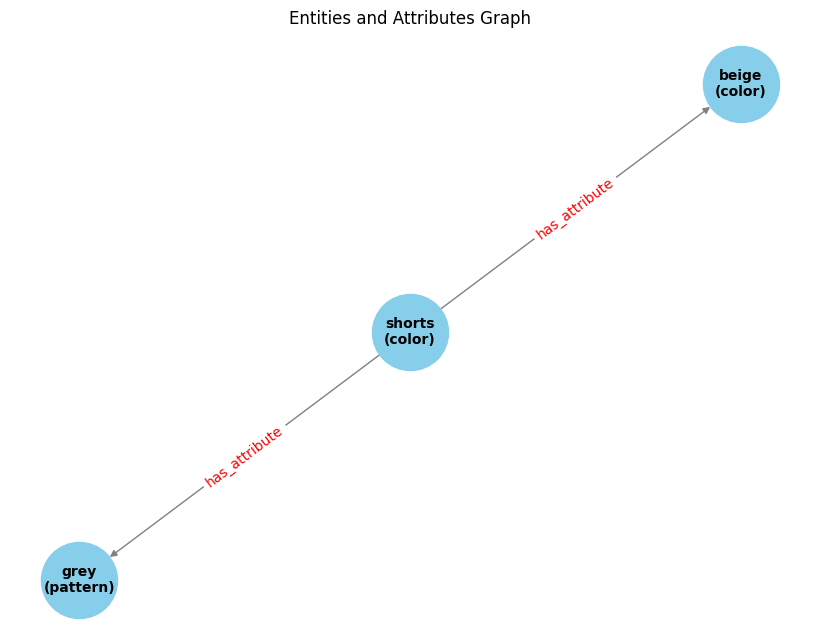

In [24]:
import networkx as nx
import matplotlib.pyplot as plt

# Define the data
data = {
    "entities": [
        {"type": "clothing", "name": "shorts"},
        {"type": "color", "entity": "shorts", "value": "beige"}
    ],
    "attributes": [
        {"type": "pattern", "entity": "shorts", "value": "grey"}
    ],
    "relations": []
}

# data = {
#         "entities": [
#             {"type": "whole", "name": "shorts"}
#         ],
#         "attributes": [
#             {"type": "article", "entity": "shorts", "value": "cargo"},
#             {"type": "pattern", "entity": "shorts", "value": "patterned fabric"},
#             {"type": "location", "entity": "shorts", "value": "lower part of body"},
#             {"type": "size", "entity": "shorts", "value": "from waist to hem"}
#         ],
#         "relations": []
#     }

# Initialize a directed graph
G = nx.DiGraph()

# Add entity nodes
for entity in data["entities"]:
    if "name" in entity:
        G.add_node(entity["name"], type=entity["type"])
    else:
        G.add_node(entity["entity"], type=entity["type"])
        G.add_node(entity["value"], type=entity["type"])
        G.add_edge(entity["entity"], entity["value"], type="has_attribute")

# Add attribute nodes and edges
for attribute in data["attributes"]:
    G.add_node(attribute["value"], type=attribute["type"])
    G.add_edge(attribute["entity"], attribute["value"], type="has_attribute")

# Define node labels
node_labels = {node: f"{node}\n({G.nodes[node]['type']})" for node in G.nodes()}

# Draw the graph
pos = nx.spring_layout(G)  # positions for all nodes
plt.figure(figsize=(8, 6))
nx.draw(G, pos, with_labels=True, labels=node_labels, node_color='skyblue', node_size=3000, font_size=10, font_weight='bold', edge_color='gray')
edge_labels = nx.get_edge_attributes(G, 'type')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red')
plt.title('Entities and Attributes Graph')
plt.show()

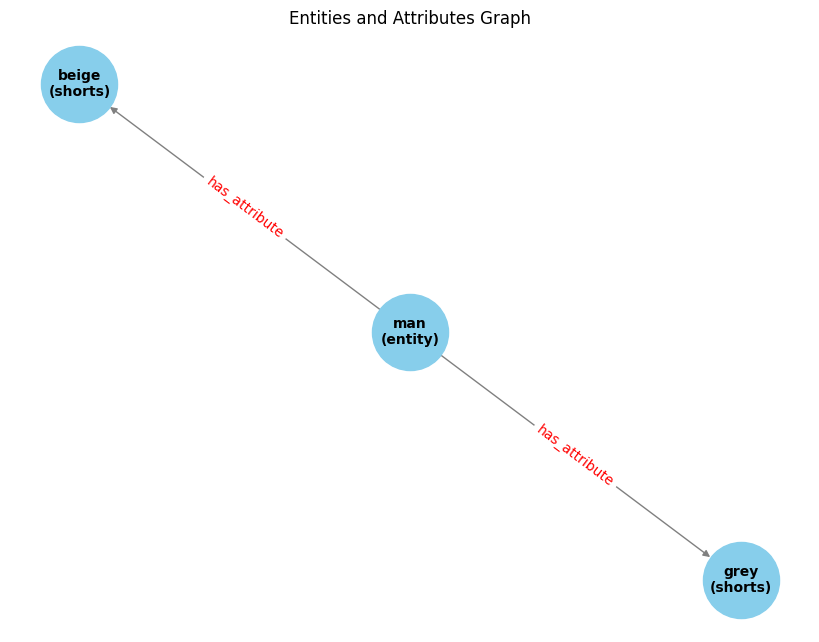

In [35]:
import networkx as nx
import matplotlib.pyplot as plt

# Define the data
data = {
    "entities": [
        {
            "type": "man",
            "name": "man",
            "value": ""
        }
    ],
    "attributes": [
        {
            "type": "shorts",
            "entity": "man",
            "value": "beige"
        },
        {
            "type": "shorts",
            "entity": "man",
            "value": "grey"
        }
    ],
    "relations": []
}

# Initialize a directed graph
G = nx.DiGraph()

# Add entity nodes
for entity in data["entities"]:
    entity_name = entity["name"] if entity["name"] else entity["type"]
    G.add_node(entity_name, type=entity["type"])

# Add attribute nodes and edges
for attribute in data["attributes"]:
    shorts_node = f"{attribute['value']}"
    G.add_node(attribute["entity"], type="entity")
    G.add_node(shorts_node, type=attribute["type"])
    G.add_edge(attribute["entity"], shorts_node, type="has_attribute")

# Define node labels
node_labels = {node: f"{node}\n({G.nodes[node]['type']})" for node in G.nodes()}

# Draw the graph
pos = nx.spring_layout(G)  # positions for all nodes
plt.figure(figsize=(8, 6))
nx.draw(G, pos, with_labels=True, labels=node_labels, node_color='skyblue', node_size=3000, font_size=10, font_weight='bold', edge_color='gray')
edge_labels = nx.get_edge_attributes(G, 'type')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red')
plt.title('Entities and Attributes Graph')
plt.show()

### Graph Edit Distance

In [45]:
!pip install grapheditdistance

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.8/54.8 kB 6.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.9/42.9 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.9/11.9 MB 23.3 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 81.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 7.0 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.7/230.7 kB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.8/247.8 kB 25

In [46]:
from grapheditdistance import TextGraph

g = TextGraph()

In [47]:
# Adding entities individually
g.add('hi')
g.add('hello')
# Adding a sequence of entities
g.index(['bye', 'goodbye', 'point of sale', 'pointing'])

In [68]:
## With the help of n-gram graphs

import networkx as nx
import nltk
from nltk.util import ngrams
from collections import defaultdict, Counter

nltk.download('punkt')

def create_ngram_graph(text, n):
    words = nltk.word_tokenize(text)
    n_grams = ngrams(words, n)
    graph = nx.DiGraph()
    edges = defaultdict(int)

    for n_gram in n_grams:
        for i in range(len(n_gram) - 1):
            for j in range(i + 1, len(n_gram)):
                edges[(n_gram[i], n_gram[j])] += 1

    for (node1, node2), weight in edges.items():
        if not graph.has_node(node1):
            graph.add_node(node1)
        if not graph.has_node(node2):
            graph.add_node(node2)
        graph.add_edge(node1, node2, weight=weight)

    return graph

# Example usage
text = "A sample text for creating n-gram graphs."
n = 2
ngram_graph = create_ngram_graph(text, n)

def value_similarity(G1, G2):
    common_edges = set(G1.edges()).intersection(set(G2.edges()))
    if not common_edges:
        return 0.0
    value_sim = 0.0
    for edge in common_edges:
        w1 = G1[edge[0]][edge[1]]['weight']
        w2 = G2[edge[0]][edge[1]]['weight']
        value_sim += min(w1, w2) / max(w1, w2)
    return value_sim / max(len(G1.edges()), len(G2.edges()))

def size_similarity(G1, G2):
    return min(len(G1.edges()), len(G2.edges())) / max(len(G1.edges()), len(G2.edges()))

def normalized_value_similarity(G1, G2):
    ss = size_similarity(G1, G2)
    if ss == 0:
        return 0.0
    return value_similarity(G1, G2) / ss

# Example comparison
# text1 = "A sample text for creating n-gram graphs."
# text2 = "Another text for generating n-gram graphs."

text1 = "The caption describes a vehicle that is participating in the Mongol Rally with a bathtub on top. This is the most accurately depicted in the image, as it shows a car with an object placed on its roof, which is a tub. The text also references the Mongol Rally '09, which is consistent with the timestamp on the photo. No other choice quite accurately captures all elements shown in the image"
text2 = "The image shows a small, modified car decorated with paint, flames on the hood, and a bathtub on top. It participates in the Mongol Rally, which suggests some level of adventurous spirit. The presence of people and the racing theme indicated by 'Norfolk Race car' is also represented in the caption. Thus, 'A' is the most correct order in terms of constituent presence in the image."
text3 = "The image displays a car that is participating in the Mongol Rally in '09, which refers to an annual charity drive where people drive from one end of the Eurasian landmass to the other. This particular car is also decorated with a bathtub on its outdoor roof, as is common in the rally for decorative purposes, and flags are attached. The presence of the tub and the decorations are distinct features which point to the event the car is participating in, and '09 is likely the year the event took place. Hence, option B is the best answer."

text1 = "A sample text for creating n-gram graphs."
text2 = "Another text for generating n-gram graphs."

n = 4

graph1 = create_ngram_graph(text1, n)
graph2 = create_ngram_graph(text2, n)

vs = value_similarity(graph1, graph2)
ss = size_similarity(graph1, graph2)
nvs = normalized_value_similarity(graph1, graph2)

print(f"Value Similarity: {vs}")
print(f"Size Similarity: {ss}")
print(f"Normalized Value Similarity: {nvs}")

total_sim = (vs + ss + nvs) / 3
print(f"Total Similarity: {total_sim}")

Value Similarity: 0.37037037037037035
Size Similarity: 0.8333333333333334
Normalized Value Similarity: 0.4444444444444444
Total Similarity: 0.5493827160493827


[nltk_data] Downloading package punkt to /home/ubuntu/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


[nltk_data] Downloading package punkt to /home/ubuntu/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


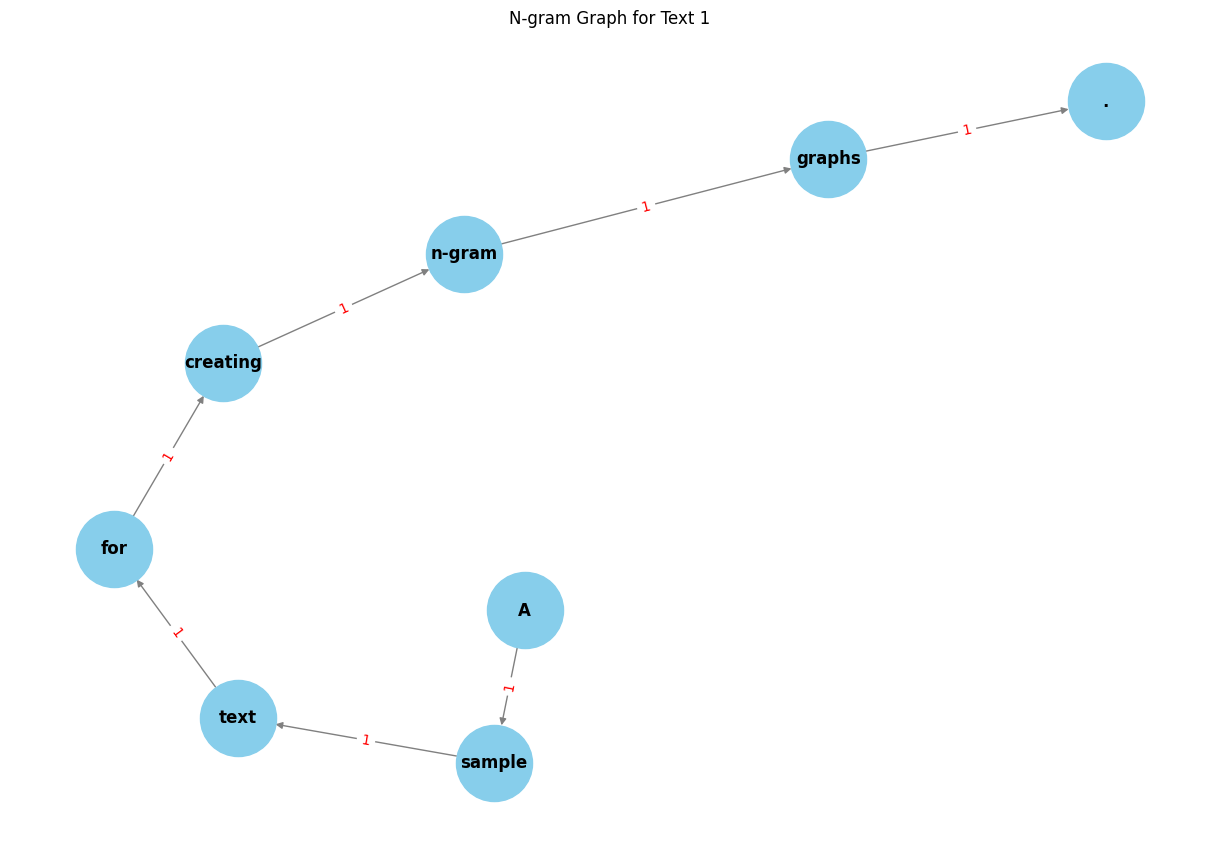

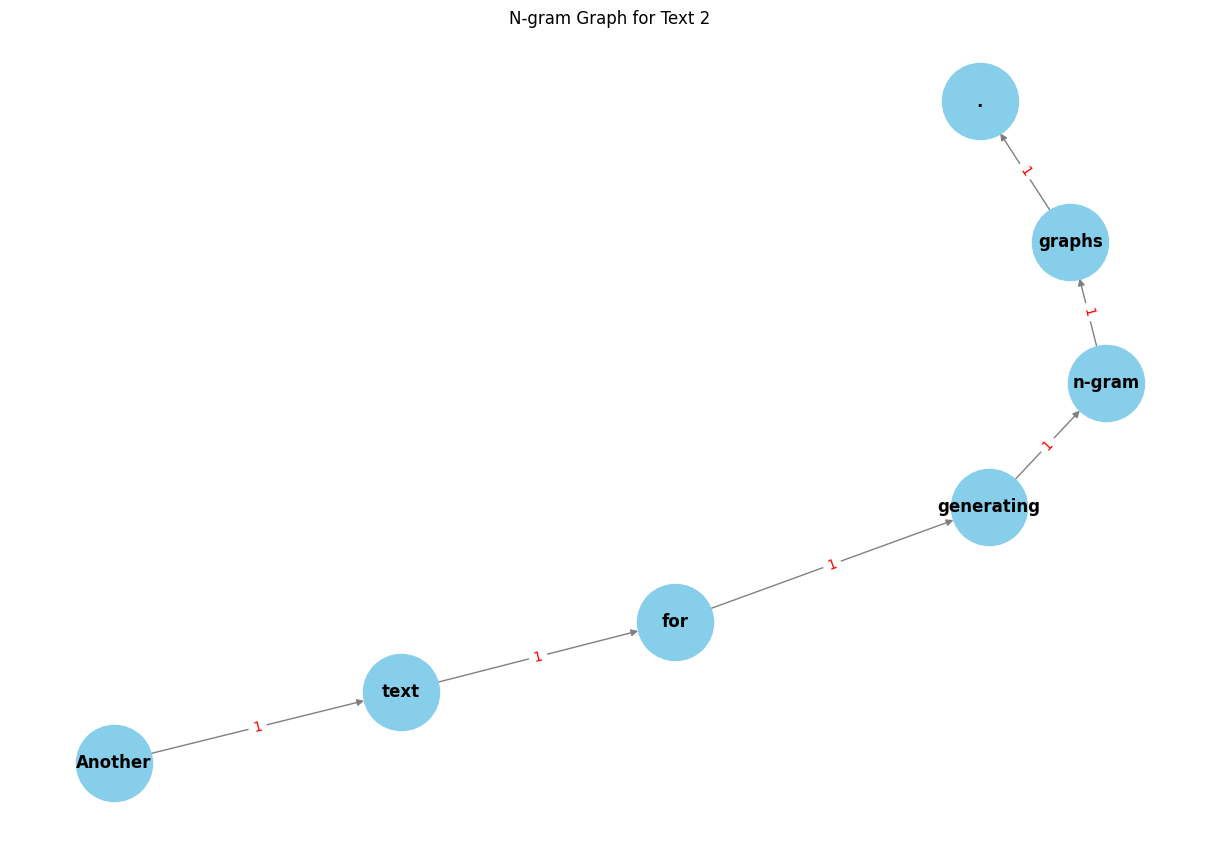

In [62]:
import networkx as nx
import matplotlib.pyplot as plt
import nltk
from nltk.util import ngrams
from collections import defaultdict

nltk.download('punkt')

def create_ngram_graph(text, n):
    words = nltk.word_tokenize(text)
    n_grams = ngrams(words, n)
    graph = nx.DiGraph()
    edges = defaultdict(int)

    for n_gram in n_grams:
        for i in range(len(n_gram) - 1):
            for j in range(i + 1, len(n_gram)):
                edges[(n_gram[i], n_gram[j])] += 1

    for (node1, node2), weight in edges.items():
        if not graph.has_node(node1):
            graph.add_node(node1)
        if not graph.has_node(node2):
            graph.add_node(node2)
        graph.add_edge(node1, node2, weight=weight)

    return graph

def visualize_graph(graph, title):
    pos = nx.spring_layout(graph)
    plt.figure(figsize=(12, 8))
    nx.draw(graph, pos, with_labels=True, node_color='skyblue', node_size=3000, edge_color='gray', font_size=12, font_weight='bold')
    edge_labels = nx.get_edge_attributes(graph, 'weight')
    nx.draw_networkx_edge_labels(graph, pos, edge_labels=edge_labels, font_color='red')
    plt.title(title)
    plt.show()

# Example usage
text1 = "A sample text for creating n-gram graphs."
text2 = "Another text for generating n-gram graphs."
n = 2

graph1 = create_ngram_graph(text1, n)
graph2 = create_ngram_graph(text2, n)

visualize_graph(graph1, "N-gram Graph for Text 1")
visualize_graph(graph2, "N-gram Graph for Text 2")